Lab 4
=====

*Introduction to Data Science and Visualization*


### Objectives

1.  Query dataset
2.  Basic plots

### Tool

Python, in particular the `pandas` and `matplotlib` libraries:

In [153]:
import pandas as pd
import matplotlib.pyplot as plt

### Dataset

We use the public dataset about Italian employment data from ISTAT with updated to January 2026, published on March 4, 2026:

<https://www.istat.it/comunicato-stampa/occupati-e-disoccupati-dati-provvisori-gennaio-2026>

In [154]:
import os
import urllib.request

url = 'https://www.istat.it/wp-content/uploads/2026/03/202601_serie-storiche.xlsx'
file = url.split("/")[-1]
if not os.path.exists(file):
    urllib.request.urlretrieve(url, file)

istat = pd.read_excel(file, sheet_name="Tab1", usecols="A:P", skiprows=7).convert_dtypes()
measures = ["year", "month", "activity", "employment", "unemployment", "youth unemployment"]
col_names = ([ "all_"+m for m in measures ] + 
        [ "m_" +m for m in measures[:-1] ] + 
        [ "f_" + m for m in measures[:-1] ])
istat.columns = col_names
repeated = istat.columns.str.contains(r"[mf]_(?:year|month)")
istat = istat.loc[:,~repeated].rename(columns={'all_year':"year", 'all_month':"month"})
istat["year"] = istat["year"].ffill()
istat["year"] = istat["year"].astype(int)
# Convert month to categorical preserving order of appearance
month_order = list(istat["month"].unique())  # unique, order-preserving
istat["month"] = pd.Categorical(istat["month"], categories=month_order, ordered=True)
value_cols = istat.columns[2:].tolist()  # all columns except year and month
istat_long = istat.melt(id_vars=["year", "month"], value_vars=value_cols,
                        var_name="variable", value_name="value")
istat_long[["sex", "indicator"]] = istat_long["variable"].str.split("_", n=1, expand=True)
istat_long = istat_long.drop(columns="variable")
istat = istat_long.pivot_table(index=["year", "month", "sex"],
                               columns="indicator", values="value",
                               aggfunc="first").reset_index()
istat.columns.name = None
istat["sex"] = istat["sex"].astype("category")
istat["date"] = pd.to_datetime(
    istat["year"].astype(str) + "-" +
    (istat["month"].cat.codes + 1).astype(str) + "-1"
) + pd.offsets.MonthEnd(0)
# Reorder columns: data first, then the rest
cols = ["date"] + [c for c in istat.columns if c != "date"]
istat = istat[cols]
istat

,date,year,month,sex,activity,employment,unemployment,youth unemployment
0,2004-01-31,2004,Gennaio,all,62.51201,57.251936,8.339635,22.883
1,2004-01-31,2004,Gennaio,f,50.899031,45.130214,11.268679,<NA>
2,2004-01-31,2004,Gennaio,m,74.232631,69.486015,6.332135,<NA>
3,2004-02-29,2004,Febbraio,all,62.363788,57.312528,8.032435,22.372344
4,2004-02-29,2004,Febbraio,f,50.651898,45.231674,10.651987,<NA>
...,...,...,...,...,...,...,...,...
790,2025-12-31,2025,Dicembre,f,57.264904,53.934269,5.669447,<NA>
791,2025-12-31,2025,Dicembre,m,75.022661,70.844568,5.404148,<NA>
792,2026-01-31,2026,Gennaio,all,66.085483,62.603115,5.133663,18.913953
793,2026-01-31,2026,Gennaio,f,57.009141,53.874763,5.342522,<NA>


## Queries

### Overall unemployment

Show in a table the trend of the unemployment rate over the years and months for *all*

In [155]:
istat.query("sex=='all'").set_index(["year","month"])["unemployment"].to_frame()

unemployment
year month                  
2004 Gennaio        8.339635
     Febbraio       8.032435
     Marzo          8.334358
     Aprile         8.114749
     Maggio         8.141401
...                      ...
2025 Settembre      5.976135
     Ottobre        5.759303
     Novembre       5.586209
     Dicembre       5.517798
2026 Gennaio        5.133663

[265 rows x 1 columns]

Plot the evolution in time of *unemployment* using a line plot

(Hint: use the `date` column)

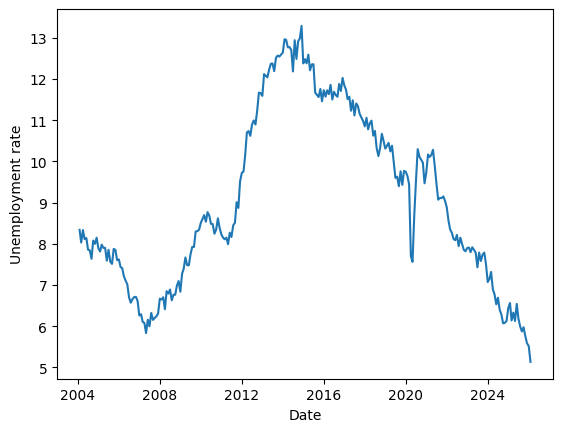

In [156]:
plt.plot("date","unemployment",data=istat.query("sex=='all'"))
plt.xlabel("Date")
plt.ylabel("Unemployment rate")
plt.show()

Show a table containing the **annual average** of the unemployment rate over the years for All (males+females).

In [157]:
unemployment_per_year = istat.query("sex=='all'").groupby("year").agg({"unemployment":"mean"})
unemployment_per_year

,unemployment
year,
2004,8.035376
2005,7.757196
2006,6.867612
2007,6.196752
2008,6.781657
2009,7.863486
2010,8.508242
2011,8.576802
2012,10.90963


Show the data using a scatter plot

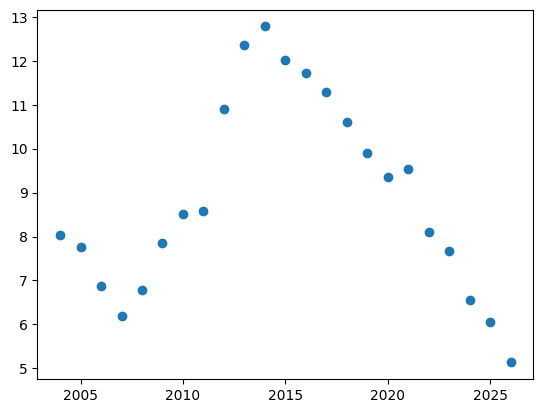

In [158]:
plt.scatter("year","unemployment", data=unemployment_per_year.reset_index())
plt.show()

### Unemployment per sex

Show in a table the trend of the unemployment rate over the years for Males and Females (in two side-by-side columns).

In [159]:
unemployment_per_sex = (
    istat.query("sex!='all'")
    .pivot(
        index=["year","month"],
        columns="sex",
        values="unemployment"
    )
    .rename(columns={"f":"female_unemployment","m":"male_unemployment"})
)
unemployment_per_sex

sex             female_unemployment  male_unemployment
year month                                            
2004 Gennaio              11.268679           6.332135
     Febbraio             10.651987            6.24335
     Marzo                 10.93423           6.551786
     Aprile               10.825595            6.27222
     Maggio               10.528557           6.516743
...                             ...                ...
2025 Settembre             6.353743           5.691752
     Ottobre               6.109835           5.495228
     Novembre              5.834516           5.400341
     Dicembre              5.669447           5.404148
2026 Gennaio               5.342522           4.977837

[265 rows x 2 columns]

Show the evolutions of male and females in time
(Hint: use `date` column)

Text(0, 0.5, 'unemployment rate')

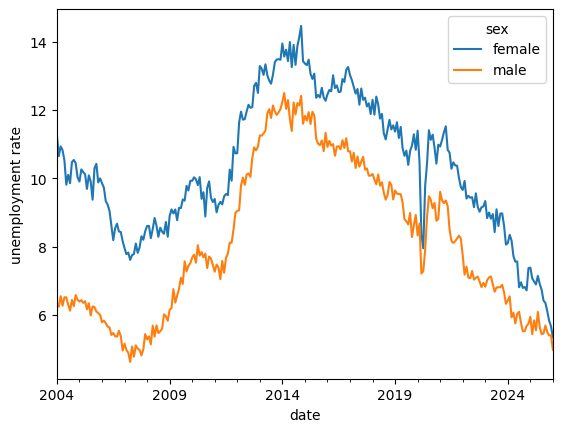

In [160]:
unemployment_per_sex_over_time = (
    istat.query("sex!='all'")
    .pivot(
        index="date",
        columns="sex",
        values="unemployment"
    )
    .rename(columns={"f":"female","m":"male"})
    .reset_index()
)

unemployment_per_sex_over_time.plot(x="date",y=["female","male"])
plt.ylabel("unemployment rate")


Show in a table the average for each year of the employment rate for Males and Females separately.

In [161]:
employment_per_sex_over_year = (
    istat.query("sex != 'all'")
    .groupby(["year", "sex"])["employment"]
    .mean()
    .unstack("sex")
    .rename(columns={"f": "avg_female_employment", "m": "avg_male_employment"})
)
employment_per_sex_over_year

sex,avg_female_employment,avg_male_employment
year,,
2004,45.476179,69.583757
2005,45.388834,69.467949
2006,46.21324,70.115854
2007,46.638638,70.274357
2008,47.175956,69.871529
2009,46.180321,67.844695
2010,45.891844,66.790178
2011,46.270571,66.555448
2012,46.722571,65.465369


Show the two trends with a line plot


Text(0, 0.5, 'employment rate')

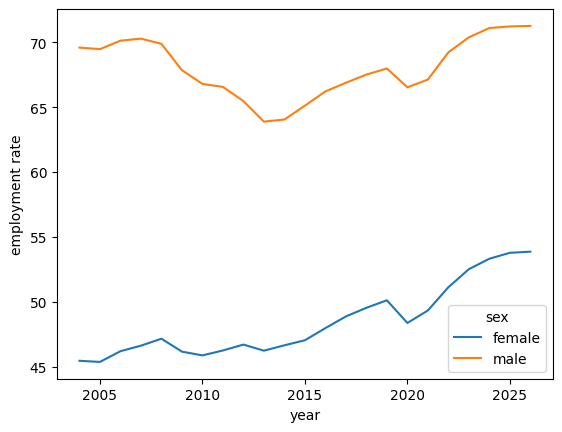

In [162]:
(
    employment_per_sex_over_year
    .rename(columns={"avg_female_employment": "female", "avg_male_employment": "male"})
    .reset_index()
    .plot(x="year", y=["female", "male"])
)
plt.ylabel("employment rate")

Show a table with the unemployment rate (for All, males+females) with one year per column as a function of the month.

In [163]:
pivot_year = (
    istat.query("sex=='all'")
    .pivot(
        index="month",
        columns="year",
        values="unemployment"
    )
)
pivot_year

year,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
month,,,,,,,,,,,,,,,,,,,,,
Gennaio,8.339635,7.813606,7.434404,6.29112,6.648723,7.277272,8.606553,8.151829,9.757473,12.121121,...,11.742237,11.060097,10.382586,9.644657,10.170909,8.563142,7.908735,7.149686,6.564199,5.133663
Febbraio,8.032435,7.980352,7.411693,6.109413,6.703561,7.391384,8.69777,8.110136,10.150917,12.084019,...,11.514042,10.78037,10.451788,9.439778,10.109768,8.356216,7.798952,7.317623,6.14103,<NA>
Marzo,8.334358,7.901169,7.212053,6.079128,6.412538,7.669447,8.536564,8.150848,10.705578,12.042038,...,11.569974,10.925048,10.245011,7.703026,10.159405,8.270207,7.916407,6.898985,6.330014,<NA>
Aprile,8.114749,7.904867,7.107862,5.83405,6.851642,7.484286,8.769463,7.99098,10.737588,12.223292,...,11.23255,10.992045,10.382722,7.563889,10.283633,8.121537,7.854206,6.776375,6.128164,<NA>
Maggio,8.141401,7.591232,7.015868,6.158296,6.79124,7.478632,8.684349,8.270729,10.622644,12.370061,...,11.484894,10.627021,9.972143,8.695057,9.887865,8.088223,7.78391,6.532011,6.542465,<NA>
Giugno,7.858464,7.854711,6.705095,5.998055,6.890652,7.743729,8.486288,8.166225,10.894418,12.379286,...,11.117687,10.741629,9.600675,9.525935,9.466849,8.217011,7.430057,6.69195,6.18753,<NA>
Luglio,7.842879,7.569844,6.571314,6.322926,6.62922,7.926321,8.479294,8.449325,10.995589,12.192841,...,11.408479,10.321346,9.630925,10.298356,9.073084,7.94472,7.789082,6.402002,5.995642,<NA>
Agosto,7.637282,7.513578,6.659027,6.153218,6.765467,7.92468,8.245997,8.511405,10.897344,12.516088,...,11.343929,10.129637,9.399886,10.115994,9.115005,8.149882,7.583522,6.282056,5.873756,<NA>
Settembre,8.080094,7.876174,6.705929,6.199853,6.764103,8.301327,8.345335,9.011198,11.229927,12.570498,...,11.158426,10.326893,9.762033,10.042182,9.110807,7.997613,7.73756,6.070483,5.976135,<NA>


### Normalization

---

**Note**

Sometimes, to compare trends that do not start from the same level, it is useful to normalize them to a common starting point. This comparison method is called *indexing*. For example, *"setting the value at time X to 100"* and then seeing how different trends evolve. Indexing allows focusing on the percentage change rather than the absolute value of the measurements.

---

Report the previous data, i.e. the trend across different years month by month with one year per column, *"setting the unemployment value in January of the year to 100"*.

In [164]:
normalized = pivot_year.apply(lambda col: col/col.loc["Gennaio"] *100)
normalized

year,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
month,,,,,,,,,,,,,,,,,,,,,
Gennaio,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
Febbraio,96.316386,102.134047,99.694515,97.111691,100.82479,101.56806,101.059855,99.488544,104.032233,99.693906,...,98.056631,97.470845,100.66652,97.875725,99.398864,97.583527,98.611877,102.348872,93.553379,<NA>
Marzo,99.936724,101.120648,97.009162,96.630298,96.447664,105.389039,99.186794,99.987966,109.716706,99.34756,...,98.532963,98.778953,98.674945,79.868325,99.886893,96.579118,100.097007,96.493538,96.43239,<NA>
Aprile,97.303407,101.167975,95.607691,92.73468,103.052,102.844665,101.89286,98.026835,110.044763,100.842917,...,95.659371,99.384707,100.00131,78.425692,101.108298,94.842956,99.310522,94.778638,93.357377,<NA>
Maggio,97.622989,97.154016,94.370282,97.888707,102.143524,102.766971,100.903916,101.458568,108.866753,102.05377,...,97.808399,96.084338,96.046813,90.154134,97.217122,94.453917,98.421682,91.360809,99.668901,<NA>
Giugno,94.230311,100.52607,90.190081,95.341608,103.638729,106.409778,98.602635,100.176598,111.652044,102.129877,...,94.681167,97.120568,92.469015,98.769039,93.077708,95.957897,93.947477,93.597817,94.261768,<NA>
Luglio,94.043432,96.880288,88.390596,100.50557,99.706665,108.91885,98.521371,103.649439,112.6889,100.591694,...,97.157628,93.320574,92.760368,106.777836,89.206225,92.778095,98.487078,89.542422,91.338517,<NA>
Agosto,91.578133,96.160185,89.570422,97.80799,101.755886,108.896301,95.810681,104.410986,111.682031,103.258502,...,96.607904,91.587235,90.535113,104.887027,89.618391,95.173968,95.887926,87.864782,89.481687,<NA>
Settembre,96.887861,100.800757,90.201299,98.549273,101.735371,114.071963,96.964894,110.542039,115.090526,103.707388,...,95.028111,93.370727,94.023136,104.121712,89.577116,93.395777,97.835621,84.905589,91.041344,<NA>


Show a line plot with a line per year reporting the unemployment normalized to 100 for January

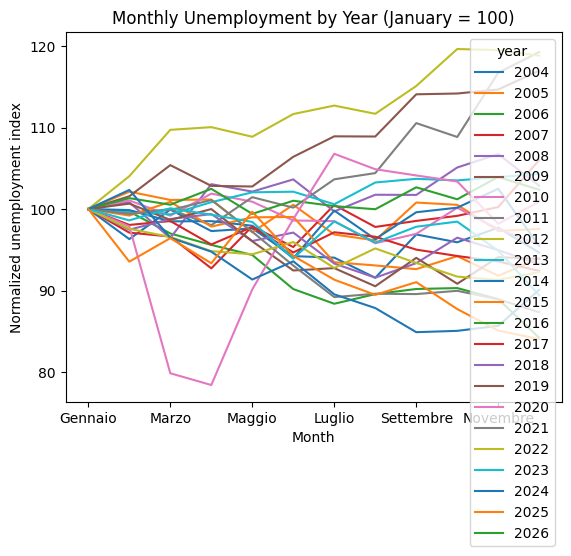

In [165]:
normalized.reset_index().plot(x="month")
plt.title("Monthly Unemployment by Year (January = 100)")
plt.ylabel("Normalized unemployment index")
plt.xlabel("Month")
plt.show()

## Data analysis


## Derived Values

From the [ISTAT methodological note](https://www.istat.it/wp-content/uploads/2026/03/CS_Occupati-e-disoccupati_GENNAIO_2026.pdf), we know that:

* **Employed**: people (aged 15–89) who have worked or are on leave
* **Unemployed**: people (aged 15–74) who are looking for work
* **Population**: people within the considered age range
* **Active population (Labour force)**: Employed + Unemployed

The **activity rate** is given by:

$$
t_A = \frac{Active}{Population}
$$

The **employment rate** is given by:

$$
t_E = \frac{Employed}{Population}
$$

The **unemployment rate** is given by:

$$
t_U = \frac{Unemployed}{Active}
$$

Starting from the values defined and provided by ISTAT, we can compute:

The **proportion of unemployed over the total population**:

$$
p_U = \frac{Unemployed}{Population} = t_U \cdot t_A
$$

The **proportion of inactive (non-active) people over the total population**:

$$
p_I = \frac{Inactive}{Population} = 1 - t_A
$$

The reference populations for Employed and Unemployed are not exactly the same, but we might expect the difference is minimal; therefore, we have:

$$
p_\text{total} = p_U + t_E + p_I \approx 1
$$

---


Verify that the distribution of the sum of the employment rate, the proportion of unemployed, and the proportion of inactive people is approximately 1.

In [166]:
import numpy as np
istat["unemployed proportion"] = (istat["unemployment"]/100)*(istat["activity"]/100)
istat = (
    istat.assign(distribution = lambda x: x["unemployed proportion"]+1-(x["activity"]/100)+(x["employment"]/100),
                 valid_distribution = lambda x: np.isclose(x["distribution"],1,atol=10**-2))
)

istat["valid_distribution"].value_counts()

valid_distribution
True    795
Name: count, dtype: int64

Show the distribution of the total for males (M), females (F), and overall (All).

In [167]:
distribution_by_sex = (
    istat.groupby("sex").apply(
        lambda df: pd.Series({
            "employment_rate": (df["employment"]/100).mean(),
            "unemployed_proportion": df["unemployed proportion"].mean(),
            "inactive_proportion": (1 - df["activity"]/100).mean()
        })
    )
)
distribution_by_sex["total"] = distribution_by_sex.sum(axis=1)
distribution_by_sex

,employment_rate,unemployed_proportion,inactive_proportion,total
sex,,,,
all,0.580266,0.057841,0.361037,0.999144
f,0.482499,0.055594,0.461358,0.999452
m,0.678825,0.060182,0.259895,0.998903
